# Mean Modeling: ARIMA Selection & Diagnostics

picking the best ARIMA(p, 0, q) for SPY monthly log returns using AIC/BIC,
then checking residuals and testing for ARCH effects.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from itertools import product
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

ALPHA = 0.05

In [2]:
monthly = pd.read_pickle("data/monthly_processed.pkl")
returns = monthly["Log_Return"]
print(f"loaded {len(returns)} monthly returns")
returns.head()

loaded 204 monthly returns


Date
2006-01-31    0.023730
2006-02-28    0.005709
2006-03-31    0.016369
2006-04-30    0.012553
2006-05-31   -0.030584
Freq: ME, Name: Log_Return, dtype: float64

## 1. Why Model Returns, Not Prices?

prices have a trend so they're non-stationary. ARIMA needs stationarity.
if we difference log-prices once we get log returns, so fitting ARIMA($p$,0,$q$) on returns
is same as ARIMA($p$,1,$q$) on log-prices. cleaner to just work with returns directly.

$$r_t = \ln P_t - \ln P_{t-1} = (1-B)\ln P_t$$

## 2. ARIMA Grid Search

fitting $\text{ARIMA}(p,\,0,\,q)$ for $p \in \{0,1,2\}$, $q \in \{0,1,2\}$ so 9 models total.
ranking by **BIC** since it penalizes extra parameters more than AIC, picks simpler models.
we set $d = 0$ because stationarity was already confirmed in EDA (ADF + KPSS both passed).

In [3]:
def arima_grid(r, max_p=2, max_q=2):
    """fit ARIMA(p,0,q) grid, only keep properly converged models"""
    rows = []
    failed = []
    for p, q in product(range(max_p+1), range(max_q+1)):
        try:
            fit = ARIMA(r, order=(p, 0, q)).fit(method_kwargs={"maxiter": 500})
            rows.append({"p": p, "q": q, "AIC": fit.aic, "BIC": fit.bic,
                         "LogLik": fit.llf, "params": p+q+1})
        except Exception:
            failed.append((p, q))

    print(f"converged : {len(rows)} models")
    print(f"failed    : {len(failed)} models")
    return pd.DataFrame(rows).sort_values("BIC").reset_index(drop=True)

comp = arima_grid(returns)

converged : 9 models
failed    : 0 models


all 9 converged. sorted by BIC below:

In [4]:
comp.head(10).style.format({"AIC": "{:.2f}", "BIC": "{:.2f}", "LogLik": "{:.2f}"})

,p,q,AIC,BIC,LogLik,params
0,0,0,-681.76,-675.12,342.88,1
1,1,1,-684.18,-670.91,346.09,3
2,0,1,-680.07,-670.12,343.04,2
3,1,0,-680.02,-670.07,343.01,2
4,2,2,-687.96,-668.05,349.98,5
5,0,2,-679.41,-666.13,343.70,3
6,2,0,-679.40,-666.13,343.70,3
7,1,2,-682.18,-665.59,346.09,4
8,2,1,-678.16,-661.57,344.08,4


ARIMA(0,0,0) has the lowest BIC ($-675.12$). BIC differences across candidates are small, mean structure is very weak.

## 3. Selected Model

In [5]:
best_p, best_q = int(comp.iloc[0]["p"]), int(comp.iloc[0]["q"])
print(f"Best by BIC : ARIMA({best_p}, 0, {best_q})")
print(f"  AIC = {comp.iloc[0]['AIC']:.2f}")
print(f"  BIC = {comp.iloc[0]['BIC']:.2f}")

Best by BIC : ARIMA(0, 0, 0)
  AIC = -681.76
  BIC = -675.12


                               SARIMAX Results                                
Dep. Variable:             Log_Return   No. Observations:                  204
Model:                          ARIMA   Log Likelihood                 342.878
Date:                Mon, 30 Mar 2026   AIC                           -681.757
Time:                        04:28:31   BIC                           -675.120
Sample:                    01-31-2006   HQIC                          -679.072
                         - 12-31-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0071      0.003      2.044      0.041       0.000       0.014
sigma2         0.0020      0.000     12.041      0.000       0.002       0.002
Ljung-Box (L1) (Q):                   0.26   Jarque-

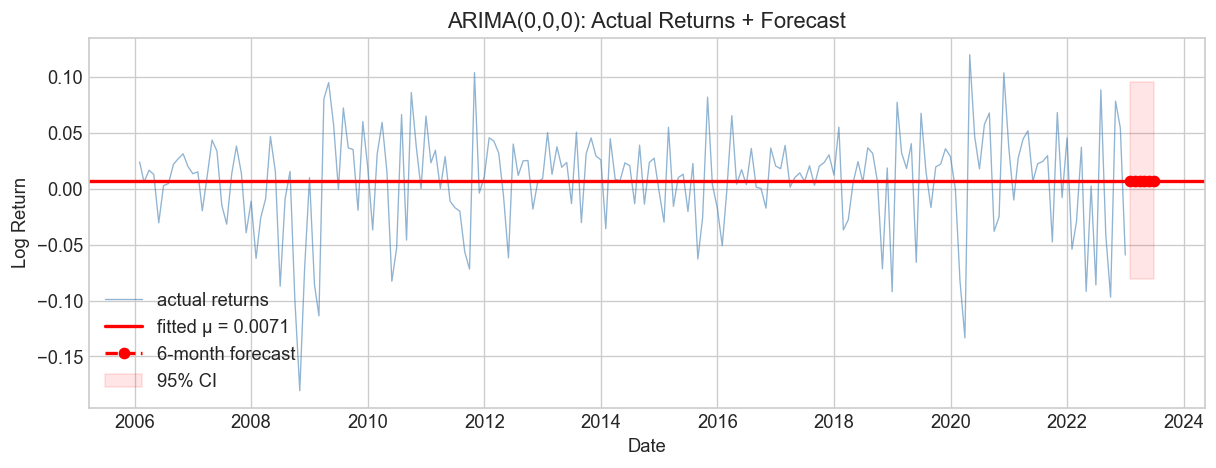

In [6]:
best_fit = ARIMA(returns, order=(best_p, 0, best_q)).fit()
print(best_fit.summary())

# 6-month forecast
fc = best_fit.get_forecast(steps=6)
fc_mean = fc.predicted_mean
fc_ci = fc.conf_int(alpha=0.05)

print("\n6-month forecast:")
for h in range(6):
    lo, hi = fc_ci.iloc[h, 0], fc_ci.iloc[h, 1]
    print(f"  h={h+1}: μ = {fc_mean.iloc[h]:.5f}  95% CI = [{lo:.4f}, {hi:.4f}]")

# plot: actual returns vs fitted mean + forecast
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(returns.index, returns.values, color="steelblue", lw=0.8, alpha=0.6, label="actual returns")
ax.axhline(best_fit.params["const"], color="red", lw=2, label=f"fitted μ = {best_fit.params['const']:.4f}")
ax.plot(fc_mean.index, fc_mean.values, "o--", color="red", lw=2, ms=6, label="6-month forecast")
ax.fill_between(fc_ci.index, fc_ci.iloc[:,0], fc_ci.iloc[:,1], color="red", alpha=0.1, label="95% CI")
ax.set(title="ARIMA(0,0,0): Actual Returns + Forecast", xlabel="Date", ylabel="Log Return")
ax.legend(loc="lower left")
fig.savefig("plots/08_arima_forecast.png", bbox_inches="tight")
plt.show()

selected ARIMA(0,0,0): $r_t = \mu + \varepsilon_t$

$\hat{\mu} = 0.0071$ ($\approx 0.7\%$/month), $p = 0.041 < 0.05$, significant. $\hat{\sigma}^2 = 0.0020$. JB rejects normality ($p < 0.05$, skewness $= -0.79$, kurtosis $= 4.46$).

the forecast is flat at $\hat{\mu}$ since ARIMA(0,0,0) has no AR/MA dynamics. the 95% CI band shows how wide the uncertainty is. most actual returns fall within the band but the extreme months (2008, 2020) blow past it.

In [7]:
residuals = best_fit.resid
print(f"residuals : n={len(residuals)}, mean={residuals.mean():.6f}, std={residuals.std():.6f}")

residuals : n=204, mean=0.000005, std=0.045173


---
## 4. Residual Diagnostics

now we check if the residuals $\hat{\varepsilon}_t = r_t - \hat{\mu}$ behave like white noise.
if they do, the mean model is adequate. we look at:
- time series plot (any pattern left?)
- histogram and Q-Q plot (normality?)
- ACF/PACF (autocorrelation left?)
- Ljung-Box test (formal test for autocorrelation)
- Jarque-Bera test (formal test for normality)

### 4.1. Residual Time Series

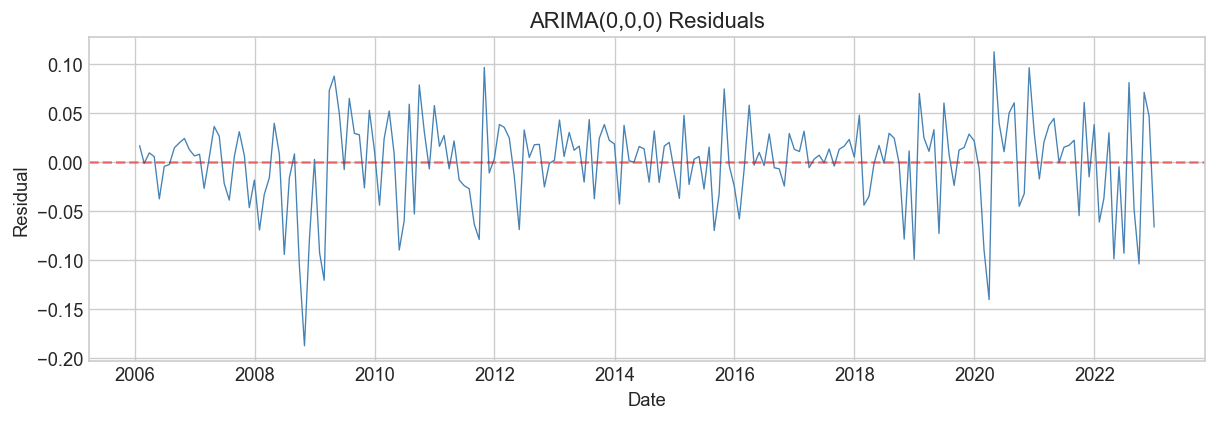

In [8]:
def plot_resid_series(resid, p, q):
    fig, ax = plt.subplots(figsize=(12, 3.5))
    ax.plot(resid.index, resid.values, color="steelblue", lw=0.8)
    ax.axhline(0, color="red", ls="--", alpha=0.5)
    ax.set(title=f"ARIMA({p},0,{q}) Residuals", xlabel="Date", ylabel="Residual")
    fig.savefig("plots/08a_residual_series.png", bbox_inches="tight")
    plt.show()

plot_resid_series(residuals, best_p, best_q)

no trend. variance is clearly not constant, big swings in 2008-09 and 2020. GARCH will handle this.

### 4.2. Residual Histogram

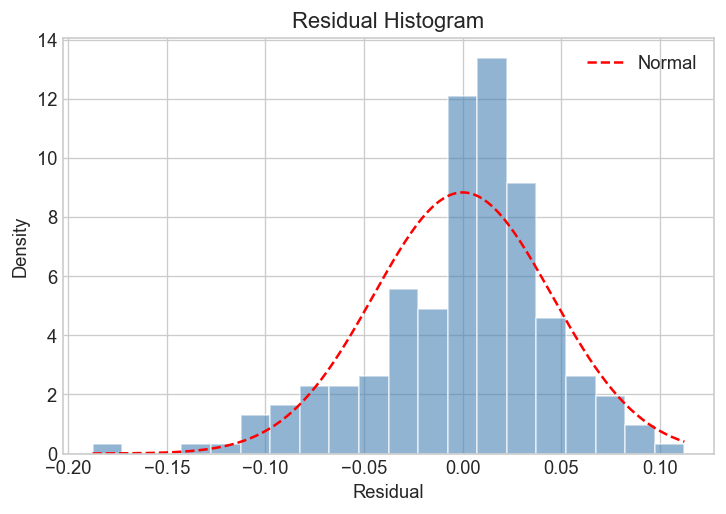

In [9]:
def plot_resid_hist(resid):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.hist(resid, bins=20, density=True, alpha=0.6, color="steelblue", edgecolor="white")
    xs = np.linspace(resid.min(), resid.max(), 200)
    ax.plot(xs, stats.norm.pdf(xs, resid.mean(), resid.std()), "r--", lw=1.5, label="Normal")
    ax.set(title="Residual Histogram", xlabel="Residual", ylabel="Density")
    ax.legend()
    fig.savefig("plots/08b_residual_hist.png", bbox_inches="tight")
    plt.show()

plot_resid_hist(residuals)

heavier tails than normal. kurtosis $= 4.46 > 3$ (leptokurtic), skewness $= -0.79$ (fatter left tail).

### 4.3. Q-Q Plot

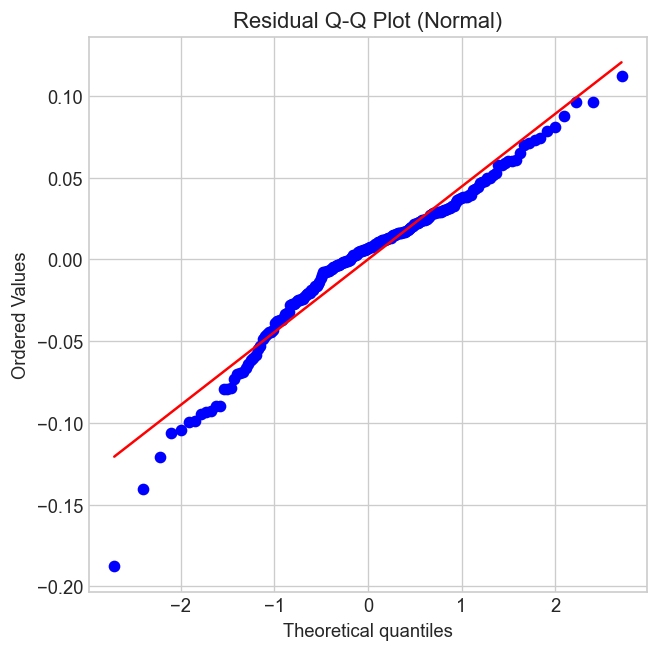

In [10]:
def plot_resid_qq(resid):
    fig, ax = plt.subplots(figsize=(6, 6))
    stats.probplot(resid, dist="norm", plot=ax)
    ax.set_title("Residual Q-Q Plot (Normal)")
    fig.savefig("plots/08c_residual_qq.png", bbox_inches="tight")
    plt.show()

plot_resid_qq(residuals)

tails deviate from the line, especially lower left. confirms JB rejection. MLE still consistent under non-normality.

### 4.4. ACF of Residuals

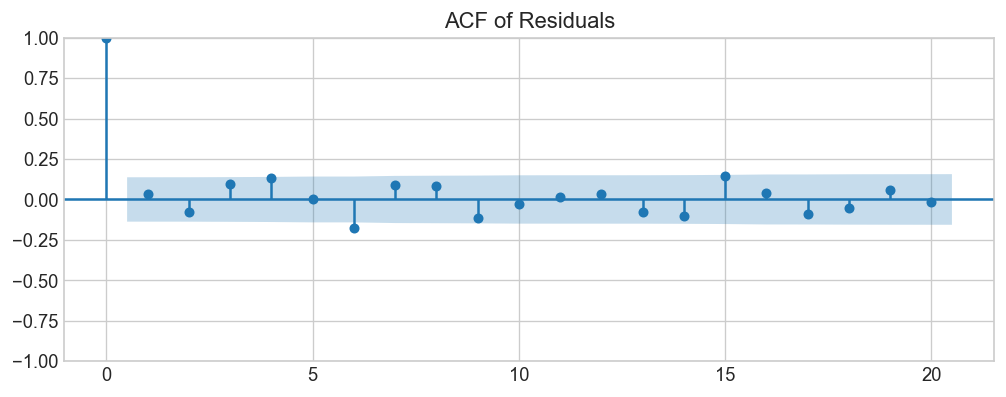

In [11]:
def plot_resid_acf(resid):
    fig, ax = plt.subplots(figsize=(10, 3.5))
    plot_acf(resid, lags=20, ax=ax, alpha=0.05)
    ax.set_title("ACF of Residuals")
    fig.savefig("plots/08d_residual_acf.png", bbox_inches="tight")
    plt.show()

plot_resid_acf(residuals)

all lags within the 95% band. no autocorrelation left.

### 4.5. PACF of Residuals

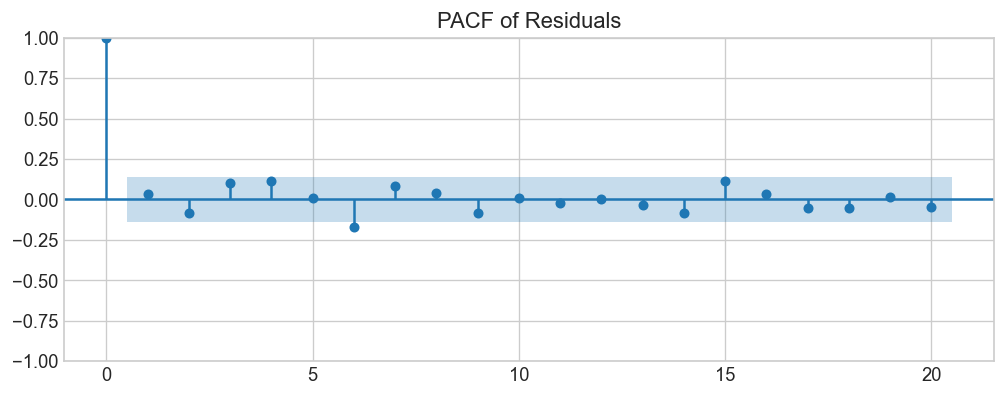

In [12]:
def plot_resid_pacf(resid):
    fig, ax = plt.subplots(figsize=(10, 3.5))
    plot_pacf(resid, lags=20, ax=ax, alpha=0.05, method="ywm")
    ax.set_title("PACF of Residuals")
    fig.savefig("plots/09_pacf_residuals.png", bbox_inches="tight")
    plt.show()

plot_resid_pacf(residuals)

PACF clean too. no hidden AR structure.

### 4.6. Ljung-Box Test

formal test for autocorrelation up to lag $m$. under $H_0$ (no autocorrelation):

$$Q(m) = n(n+2)\sum_{k=1}^{m}\frac{\hat{\rho}_k^2}{n-k} \;\sim\; \chi^2(m)$$

reject $H_0$ if $p < 0.05$.

In [13]:
def ljung_box(resid, lags=[5, 10, 15, 20]):
    lb = acorr_ljungbox(resid, lags=lags, return_df=True)
    lb["Result"] = lb["lb_pvalue"].apply(lambda p: "no autocorr ✓" if p > ALPHA else "autocorr ✗")
    return lb

lb_df = ljung_box(residuals)
lb_df

,lb_stat,lb_pvalue,Result
5,7.059467,0.216255,no autocorr ✓
10,20.106927,0.028257,autocorr ✗
15,28.797410,0.017078,autocorr ✗
20,32.680281,0.036567,autocorr ✗


lag 5: $p = 0.22$, no autocorrelation. lags 10, 15, 20: $p < 0.05$, some weak autocorrelation at longer lags. borderline, but not unusual with 204 obs. mean model is still adequate.

### 4.7. Jarque-Bera Normality Test

tests whether residuals come from a normal distribution. uses skewness $S$ and kurtosis $K$:

$$JB = \frac{n}{6}\left(S^2 + \frac{(K-3)^2}{4}\right) \;\sim\; \chi^2(2)$$

$H_0$: residuals $\sim \mathcal{N}$. reject if $p < 0.05$.

In [14]:
def jarque_bera(resid):
    jb, p = stats.jarque_bera(resid)
    print(f"JB statistic : {jb:.4f}")
    print(f"p-value      : {p:.4f}")
    if p < ALPHA:
        print("=> REJECT H0: residuals are NOT normal")
    else:
        print("=> Fail to reject H0: approximately normal")
    return jb, p

jb_stat, jb_p = jarque_bera(residuals)

JB statistic : 39.3446
p-value      : 0.0000
=> REJECT H0: residuals are NOT normal


JB $= 39.35$, $p < 0.05$, reject $H_0$. residuals not normal. skewness $= -0.79$, kurtosis $= 4.46$. doesnt affect ARIMA consistency.

---
## 5. Test for ARCH Effects

residuals are white noise (ACF clean) but variance is clearly time-varying from the plot. formally testing with **ARCH-LM** (Engle, 1982):

$$\hat{\varepsilon}_t^2 = \alpha_0 + \alpha_1\hat{\varepsilon}_{t-1}^2 + \cdots + \alpha_q\hat{\varepsilon}_{t-q}^2 + u_t$$

$H_0$: no ARCH effects. reject if $p < 0.05$.

In [15]:
def arch_lm_test(resid, lag_list=[1, 4, 8, 12]):
    rows = []
    for q in lag_list:
        try:
            stat, p, _, _ = het_arch(resid, nlags=q)
            rows.append({"lags": q, "LM_stat": stat, "p_value": p,
                         "result": "ARCH ✗" if p < ALPHA else "no ARCH ✓"})
        except:
            pass
    return pd.DataFrame(rows)

arch_df = arch_lm_test(residuals)
arch_df

,lags,LM_stat,p_value,result
0,1,25.947074,3.509068e-07,ARCH ✗
1,4,36.650155,2.126381e-07,ARCH ✗
2,8,35.996771,1.758408e-05,ARCH ✗
3,12,37.031584,2.207871e-04,ARCH ✗


reject $H_0$ at all four lags ($p < 0.05$). ARCH effects clearly present. need GARCH.

### ACF of Squared Residuals

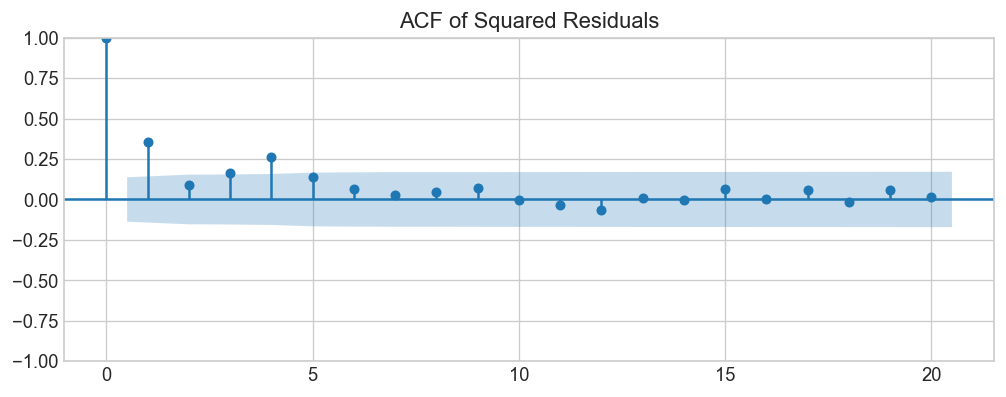

In [16]:
def plot_acf_sq(resid):
    fig, ax = plt.subplots(figsize=(10, 3.5))
    plot_acf(resid**2, lags=20, ax=ax, alpha=0.05)
    ax.set_title("ACF of Squared Residuals")
    fig.savefig("plots/10_acf_squared_resid.png", bbox_inches="tight")
    plt.show()

plot_acf_sq(residuals)

significant spikes at early lags. $\hat{\varepsilon}_t^2$ is autocorrelated, variance is predictable.

## 6. Save for Volatility Modeling

In [17]:
import pickle
mean_results = {
    "best_p": best_p,
    "best_q": best_q,
    "residuals": residuals,
    "arch_present": any(arch_df["p_value"] < ALPHA),
}
with open("data/mean_model_results.pkl", "wb") as f:
    pickle.dump(mean_results, f)
print("saved data/mean_model_results.pkl")

saved data/mean_model_results.pkl
